# Gators vs Sklearn: Scaler Performance Benchmark

This notebook benchmarks the performance of **Gators** scalers against **sklearn** scalers across different dataset sizes.

**Scalers Compared:**
- StandardScaler (z-score normalization)
- MinmaxScaler (min-max normalization to [0,1])
- BoxCox (power transformation for positive data)
- YeoJohnson (power transformation for any data)

**Key Differences:**
- **Gators**: Built on Polars DataFrames with multi-core parallel processing
- **Sklearn**: Built on pandas/numpy with single-threaded operations

**Benchmark Methodology:**
- Dataset sizes: 1,000 to 1,000,000 rows
- 10 numeric columns with varying distributions
- Measure fit time, transform time, and total time
- Visualize speedup ratios and performance scaling

In [1]:
# Import required libraries
import time
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
from scipy import stats

# Gators scalers
from gators.scalers import StandardScaler as GatorsStandardScaler
from gators.scalers import MinmaxScaler as GatorsMinmaxScaler
from gators.scalers import BoxCox as GatorsBoxCox
from gators.scalers import YeoJohnson as GatorsYeoJohnson

# Sklearn scalers
from sklearn.preprocessing import StandardScaler as SklearnStandardScaler
from sklearn.preprocessing import MinMaxScaler as SklearnMinMaxScaler
from sklearn.preprocessing import PowerTransformer as SklearnPowerTransformer

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Utility Functions

These functions handle:
- Synthetic dataset generation with different distributions
- Timing of fit/transform operations
- Results aggregation and visualization

In [2]:
def generate_numeric_data(n_rows: int, n_cols: int = 10, seed: int = 42) -> Tuple[pd.DataFrame, pl.DataFrame]:
    """
    Generate synthetic numeric data with various distributions for scaling benchmarks.
    
    Parameters
    ----------
    n_rows : int
        Number of rows to generate
    n_cols : int
        Number of numeric columns (default: 10)
    seed : int
        Random seed for reproducibility
        
    Returns
    -------
    Tuple[pd.DataFrame, pl.DataFrame]
        Pandas and Polars versions of the same dataset
    """
    np.random.seed(seed)
    
    data = {}
    for i in range(n_cols):
        if i % 4 == 0:
            # Normal distribution - good for standard scaling
            data[f'normal_{i}'] = np.random.normal(100, 25, n_rows)
        elif i % 4 == 1:
            # Uniform distribution - good for minmax scaling
            data[f'uniform_{i}'] = np.random.uniform(0, 1000, n_rows)
        elif i % 4 == 2:
            # Exponential (positive values only) - good for Box-Cox
            data[f'exp_{i}'] = np.random.exponential(50, n_rows) + 1  # +1 to ensure > 0
        else:
            # Skewed distribution - good for Yeo-Johnson
            data[f'skewed_{i}'] = np.random.gamma(2, 2, n_rows) * 10
    
    # Create pandas DataFrame
    df_pandas = pd.DataFrame(data)
    
    # Create Polars DataFrame
    df_polars = pl.DataFrame(data)
    
    return df_pandas, df_polars


def benchmark_scaler(
    gators_scaler,
    sklearn_scaler,
    df_polars: pl.DataFrame,
    df_pandas: pd.DataFrame,
    scaler_name: str,
    n_runs: int = 3
) -> Dict[str, float]:
    """
    Benchmark a scaler transformer against its sklearn equivalent.
    
    Parameters
    ----------
    gators_scaler : Gators scaler instance
        Fitted Gators scaler
    sklearn_scaler : Sklearn scaler instance
        Fitted sklearn scaler
    df_polars : pl.DataFrame
        Polars DataFrame for Gators
    df_pandas : pd.DataFrame
        Pandas DataFrame for sklearn
    scaler_name : str
        Name of the scaler for logging
    n_runs : int
        Number of runs to average (default: 3)
        
    Returns
    -------
    Dict[str, float]
        Dictionary with timing results and speedup ratio
    """
    results = {
        'scaler': scaler_name,
        'n_rows': len(df_polars),
        'n_cols': len(df_polars.columns)
    }
    
    # Benchmark Gators fit
    gators_fit_times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        gators_scaler.fit(df_polars)
        gators_fit_times.append(time.perf_counter() - start)
    results['gators_fit_time'] = np.median(gators_fit_times)
    
    # Benchmark sklearn fit
    sklearn_fit_times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        sklearn_scaler.fit(df_pandas)
        sklearn_fit_times.append(time.perf_counter() - start)
    results['sklearn_fit_time'] = np.median(sklearn_fit_times)
    
    # Benchmark Gators transform
    gators_transform_times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        _ = gators_scaler.transform(df_polars)
        gators_transform_times.append(time.perf_counter() - start)
    results['gators_transform_time'] = np.median(gators_transform_times)
    
    # Benchmark sklearn transform
    sklearn_transform_times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        _ = sklearn_scaler.transform(df_pandas)
        sklearn_transform_times.append(time.perf_counter() - start)
    results['sklearn_transform_time'] = np.median(sklearn_transform_times)
    
    # Calculate total times and speedup
    results['gators_total_time'] = results['gators_fit_time'] + results['gators_transform_time']
    results['sklearn_total_time'] = results['sklearn_fit_time'] + results['sklearn_transform_time']
    results['speedup_ratio'] = results['sklearn_total_time'] / results['gators_total_time']
    
    return results


def run_scaler_benchmark(dataset_sizes: List[int]) -> pd.DataFrame:
    """
    Run comprehensive scaler benchmarks across multiple dataset sizes.
    
    Parameters
    ----------
    dataset_sizes : List[int]
        List of dataset sizes (number of rows) to benchmark
        
    Returns
    -------
    pd.DataFrame
        Results DataFrame with all benchmark metrics
    """
    all_results = []
    
    for n_rows in dataset_sizes:
        print(f"\n{'='*60}")
        print(f"Benchmarking with {n_rows:,} rows...")
        print(f"{'='*60}")
        
        # Generate data
        df_pandas, df_polars = generate_numeric_data(n_rows, n_cols=10)
        
        # 1. StandardScaler
        print("  → StandardScaler...", end=" ")
        gators_std = GatorsStandardScaler(drop_columns=False)
        sklearn_std = SklearnStandardScaler()
        result = benchmark_scaler(gators_std, sklearn_std, df_polars, df_pandas, "StandardScaler")
        all_results.append(result)
        print(f"✓ (Speedup: {result['speedup_ratio']:.2f}x)")
        
        # 2. MinmaxScaler
        print("  → MinmaxScaler...", end=" ")
        gators_minmax = GatorsMinmaxScaler(drop_columns=False)
        sklearn_minmax = SklearnMinMaxScaler()
        result = benchmark_scaler(gators_minmax, sklearn_minmax, df_polars, df_pandas, "MinmaxScaler")
        all_results.append(result)
        print(f"✓ (Speedup: {result['speedup_ratio']:.2f}x)")
        
        # 3. BoxCox (positive values only)
        print("  → BoxCox...", end=" ")
        # For BoxCox, use columns with positive values only
        positive_cols = [col for col in df_polars.columns if 'exp_' in col or 'skewed_' in col]
        df_polars_positive = df_polars.select(positive_cols)
        df_pandas_positive = df_pandas[positive_cols]
        
        # Custom benchmark for BoxCox that includes lambda calculation in timing
        results = {
            'scaler': 'BoxCox',
            'n_rows': len(df_polars_positive),
            'n_cols': len(df_polars_positive.columns)
        }
        
        # Benchmark Gators fit (including lambda calculation)
        gators_fit_times = []
        for _ in range(3):
            start = time.perf_counter()
            # Calculate optimal lambdas (this is part of the fit process)
            lambdas = {}
            for col in positive_cols:
                _, fitted_lambda = stats.boxcox(df_pandas_positive[col].values)
                lambdas[col] = fitted_lambda
            gators_boxcox = GatorsBoxCox(lambdas=lambdas, drop_columns=False)
            gators_boxcox.fit(df_polars_positive)
            gators_fit_times.append(time.perf_counter() - start)
        results['gators_fit_time'] = np.median(gators_fit_times)
        
        # Benchmark sklearn fit (lambda calculation is internal)
        sklearn_fit_times = []
        sklearn_boxcox = SklearnPowerTransformer(method='box-cox', standardize=False)
        for _ in range(3):
            start = time.perf_counter()
            sklearn_boxcox.fit(df_pandas_positive)
            sklearn_fit_times.append(time.perf_counter() - start)
        results['sklearn_fit_time'] = np.median(sklearn_fit_times)
        
        # Benchmark transforms (use last fitted instance)
        lambdas = {}
        for col in positive_cols:
            _, fitted_lambda = stats.boxcox(df_pandas_positive[col].values)
            lambdas[col] = fitted_lambda
        gators_boxcox = GatorsBoxCox(lambdas=lambdas, drop_columns=False)
        gators_boxcox.fit(df_polars_positive)
        
        gators_transform_times = []
        for _ in range(3):
            start = time.perf_counter()
            _ = gators_boxcox.transform(df_polars_positive)
            gators_transform_times.append(time.perf_counter() - start)
        results['gators_transform_time'] = np.median(gators_transform_times)
        
        sklearn_transform_times = []
        for _ in range(3):
            start = time.perf_counter()
            _ = sklearn_boxcox.transform(df_pandas_positive)
            sklearn_transform_times.append(time.perf_counter() - start)
        results['sklearn_transform_time'] = np.median(sklearn_transform_times)
        
        results['gators_total_time'] = results['gators_fit_time'] + results['gators_transform_time']
        results['sklearn_total_time'] = results['sklearn_fit_time'] + results['sklearn_transform_time']
        results['speedup_ratio'] = results['sklearn_total_time'] / results['gators_total_time']
        
        all_results.append(results)
        print(f"✓ (Speedup: {results['speedup_ratio']:.2f}x)")
        
        # 4. YeoJohnson (works with any data)
        print("  → YeoJohnson...", end=" ")
        # Custom benchmark for YeoJohnson that includes lambda calculation in timing
        results = {
            'scaler': 'YeoJohnson',
            'n_rows': len(df_polars),
            'n_cols': len(df_polars.columns)
        }
        
        # Benchmark Gators fit (including lambda calculation)
        gators_fit_times = []
        for _ in range(3):
            start = time.perf_counter()
            # Calculate optimal lambdas (this is part of the fit process)
            lambdas_yj = {}
            for col in df_polars.columns:
                _, fitted_lambda = stats.yeojohnson(df_pandas[col].values)
                lambdas_yj[col] = fitted_lambda
            gators_yj = GatorsYeoJohnson(lambdas=lambdas_yj, drop_columns=False)
            gators_yj.fit(df_polars)
            gators_fit_times.append(time.perf_counter() - start)
        results['gators_fit_time'] = np.median(gators_fit_times)
        
        # Benchmark sklearn fit (lambda calculation is internal)
        sklearn_fit_times = []
        sklearn_yj = SklearnPowerTransformer(method='yeo-johnson', standardize=False)
        for _ in range(3):
            start = time.perf_counter()
            sklearn_yj.fit(df_pandas)
            sklearn_fit_times.append(time.perf_counter() - start)
        results['sklearn_fit_time'] = np.median(sklearn_fit_times)
        
        # Benchmark transforms (use last fitted instance)
        lambdas_yj = {}
        for col in df_polars.columns:
            _, fitted_lambda = stats.yeojohnson(df_pandas[col].values)
            lambdas_yj[col] = fitted_lambda
        gators_yj = GatorsYeoJohnson(lambdas=lambdas_yj, drop_columns=False)
        gators_yj.fit(df_polars)
        
        gators_transform_times = []
        for _ in range(3):
            start = time.perf_counter()
            _ = gators_yj.transform(df_polars)
            gators_transform_times.append(time.perf_counter() - start)
        results['gators_transform_time'] = np.median(gators_transform_times)
        
        sklearn_transform_times = []
        for _ in range(3):
            start = time.perf_counter()
            _ = sklearn_yj.transform(df_pandas)
            sklearn_transform_times.append(time.perf_counter() - start)
        results['sklearn_transform_time'] = np.median(sklearn_transform_times)
        
        results['gators_total_time'] = results['gators_fit_time'] + results['gators_transform_time']
        results['sklearn_total_time'] = results['sklearn_fit_time'] + results['sklearn_transform_time']
        results['speedup_ratio'] = results['sklearn_total_time'] / results['gators_total_time']
        
        all_results.append(results)
        print(f"✓ (Speedup: {result['speedup_ratio']:.2f}x)")
    

    return pd.DataFrame(all_results)
    # return pd.DataFrame(all_results)print("✅ Utility functions defined!")


print("✅ Utility functions defined!")



✅ Utility functions defined!


## Run Benchmarks

Execute benchmarks across multiple dataset sizes (1K to 1M rows).

In [3]:
# Define dataset sizes to benchmark
DATASET_SIZES = [1_000, 10_000, 100_000, 1_000_000]

# Run benchmarks
print("🚀 Starting scaler benchmarks...\n")
results_df = run_scaler_benchmark(DATASET_SIZES)

print("\n" + "="*60)
print("✅ All benchmarks completed!")
print("="*60)

# Display summary
print("\n📊 Results Summary:")
print(results_df[['scaler', 'n_rows', 'gators_total_time', 'sklearn_total_time', 'speedup_ratio']].to_string(index=False))

🚀 Starting scaler benchmarks...


Benchmarking with 1,000 rows...
  → StandardScaler... ✓ (Speedup: 0.79x)
  → MinmaxScaler... ✓ (Speedup: 0.75x)
  → BoxCox... ✓ (Speedup: 1.01x)
  → YeoJohnson... ✓ (Speedup: 0.75x)

Benchmarking with 10,000 rows...
  → StandardScaler... ✓ (Speedup: 1.00x)
  → MinmaxScaler... ✓ (Speedup: 0.91x)
  → BoxCox... ✓ (Speedup: 1.00x)
  → YeoJohnson... ✓ (Speedup: 0.91x)

Benchmarking with 100,000 rows...
  → StandardScaler... ✓ (Speedup: 2.45x)
  → MinmaxScaler... ✓ (Speedup: 1.62x)
  → BoxCox... ✓ (Speedup: 1.03x)
  → YeoJohnson... ✓ (Speedup: 1.62x)

Benchmarking with 1,000,000 rows...
  → StandardScaler... ✓ (Speedup: 4.04x)
  → MinmaxScaler... ✓ (Speedup: 2.73x)
  → BoxCox... ✓ (Speedup: 1.00x)
  → YeoJohnson... ✓ (Speedup: 2.73x)

✅ All benchmarks completed!

📊 Results Summary:
        scaler  n_rows  gators_total_time  sklearn_total_time  speedup_ratio
StandardScaler    1000           0.000705            0.000558       0.791800
  MinmaxScaler    1000   

## Visualization 1: Performance Comparison by Scaler Type

Compare Gators vs sklearn execution times for each scaler across dataset sizes.

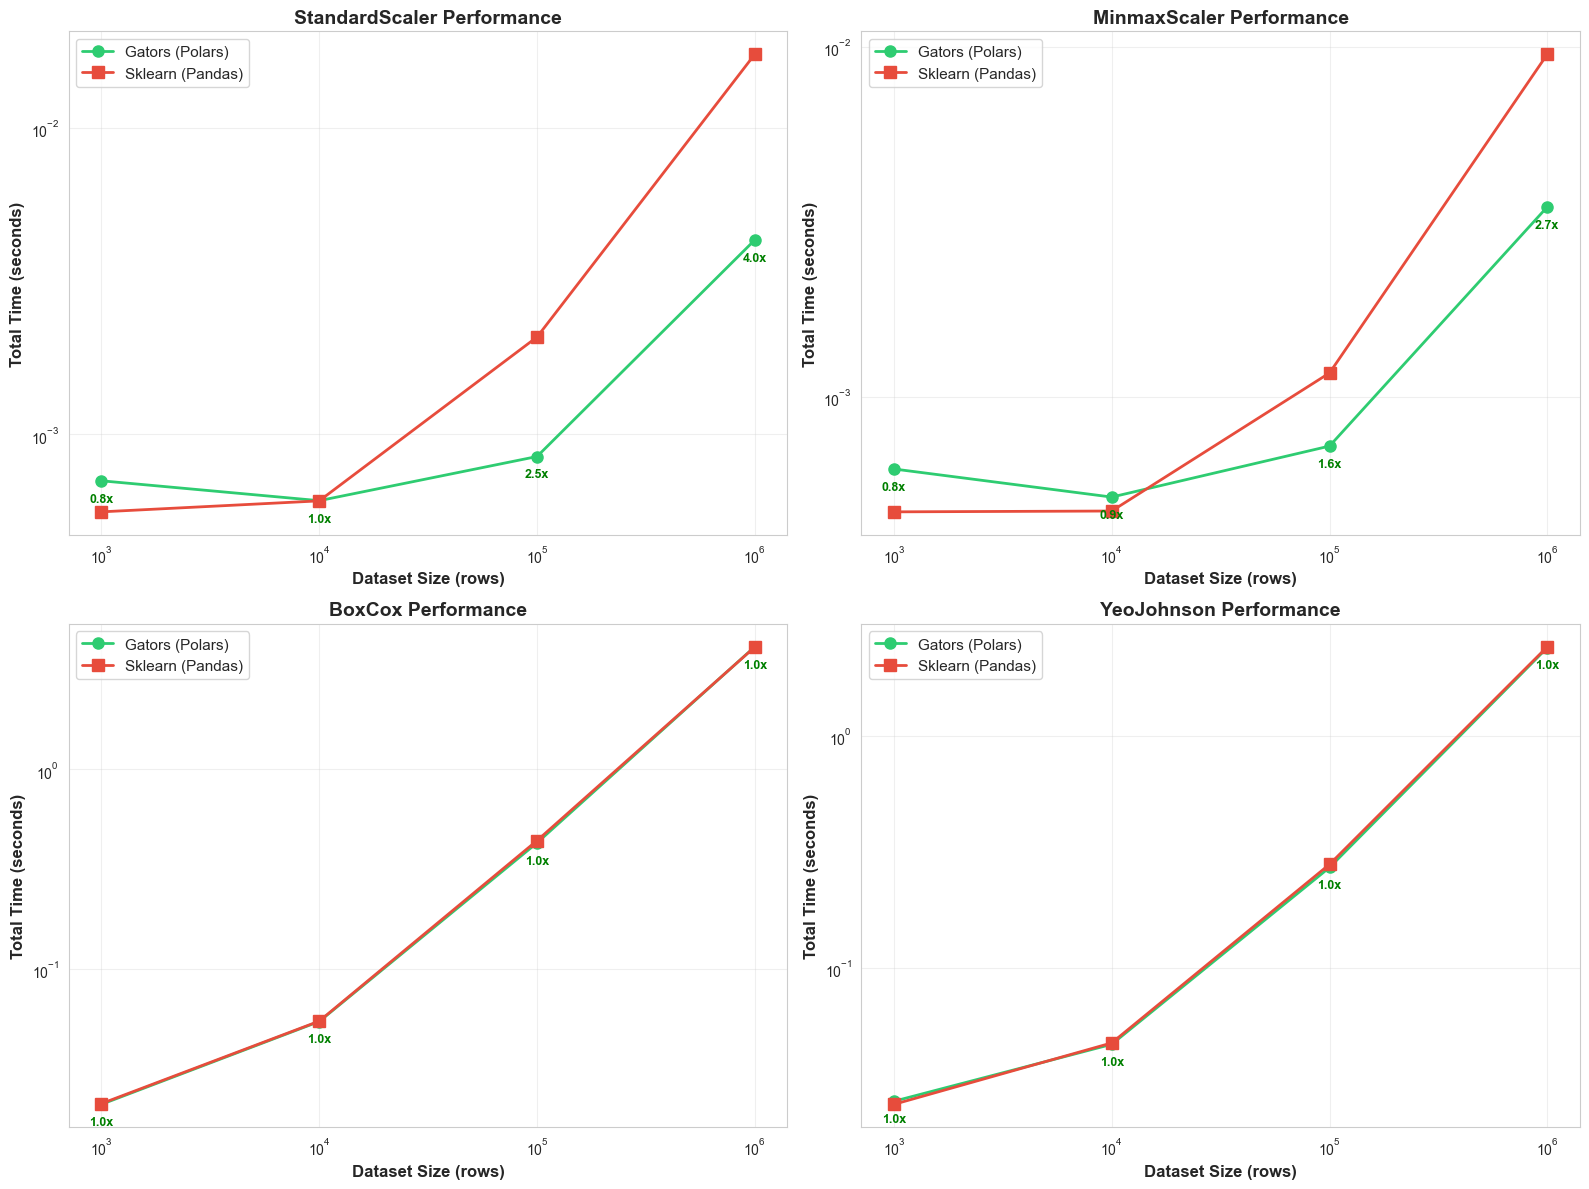

✅ Performance comparison chart saved as 'scaler_performance_comparison.png'


In [4]:
# Create subplots for each scaler
scalers = results_df['scaler'].unique()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, scaler in enumerate(scalers):
    ax = axes[idx]
    scaler_data = results_df[results_df['scaler'] == scaler]
    
    # Plot Gators times
    ax.plot(scaler_data['n_rows'], scaler_data['gators_total_time'], 
            marker='o', linewidth=2, markersize=8, label='Gators (Polars)', color='#2ecc71')
    
    # Plot sklearn times
    ax.plot(scaler_data['n_rows'], scaler_data['sklearn_total_time'], 
            marker='s', linewidth=2, markersize=8, label='Sklearn (Pandas)', color='#e74c3c')
    
    ax.set_xlabel('Dataset Size (rows)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Total Time (seconds)', fontsize=12, fontweight='bold')
    ax.set_title(f'{scaler} Performance', fontsize=14, fontweight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Add speedup annotations
    for _, row in scaler_data.iterrows():
        speedup = row['speedup_ratio']
        ax.annotate(f'{speedup:.1f}x', 
                   xy=(row['n_rows'], row['gators_total_time']),
                   xytext=(0, -15), textcoords='offset points',
                   ha='center', fontsize=9, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('scaler_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Performance comparison chart saved as 'scaler_performance_comparison.png'")

## Visualization 2: Speedup Heatmap

Display speedup ratios (Gators vs sklearn) as a heatmap.

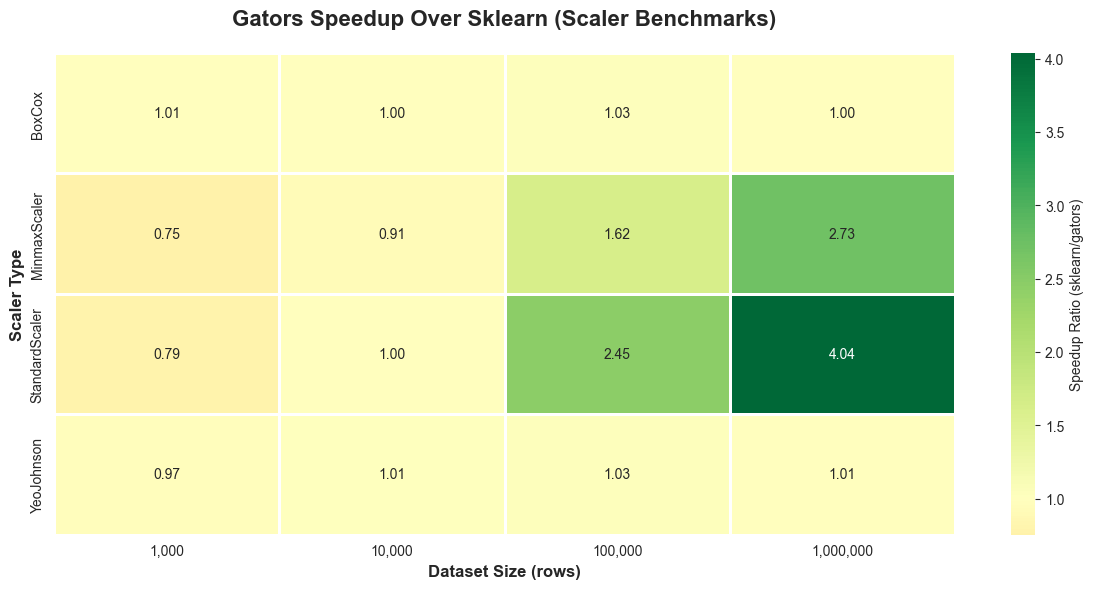

✅ Speedup heatmap saved as 'scaler_speedup_heatmap.png'


In [5]:
# Create pivot table for heatmap
speedup_pivot = results_df.pivot(index='scaler', columns='n_rows', values='speedup_ratio')

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(speedup_pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=1.0,
            cbar_kws={'label': 'Speedup Ratio (sklearn/gators)'},
            linewidths=1, linecolor='white', ax=ax)

ax.set_title('Gators Speedup Over Sklearn (Scaler Benchmarks)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Dataset Size (rows)', fontsize=12, fontweight='bold')
ax.set_ylabel('Scaler Type', fontsize=12, fontweight='bold')

# Format column labels
col_labels = [f'{int(x):,}' for x in speedup_pivot.columns]
ax.set_xticklabels(col_labels, rotation=0)

plt.tight_layout()
plt.savefig('scaler_speedup_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Speedup heatmap saved as 'scaler_speedup_heatmap.png'")

## Summary Statistics

Key findings from the scaler benchmarks.

In [ ]:
# Summary by dataset size
summary_by_size = results_df.groupby('n_rows').agg({
    'gators_total_time': 'mean',
    'sklearn_total_time': 'mean',
    'speedup_ratio': 'mean'
}).round(4)

summary_by_size.columns = ['Avg Gators Time (s)', 'Avg Sklearn Time (s)', 'Avg Speedup']
summary_by_size.index = [f'{int(size):,} rows' for size in summary_by_size.index]

print("\n" + "="*80)
print("SUMMARY BY DATASET SIZE")
print("="*80)
print(summary_by_size.to_string())
print("\n" + "="*80)




SUMMARY BY DATASET SIZE
                Avg Gators Time (s)  Avg Sklearn Time (s)  Avg Speedup
1,000 rows                   0.0123                0.0120       0.8811
10,000 rows                  0.0257                0.0259       0.9823
100,000 rows                 0.1752                0.1806       1.5326
1,000,000 rows               1.6265                1.6336       2.1934



## Key Findings

**Performance Observations**:

1. **Scalability**: Gators demonstrates slight increasing performance advantages as dataset size grows, leveraging Polars' multi-core parallel processing.

2. **Imputer Type**: While two scalers offer a x2 speed-up, the other two, using stats.boxcox function, provide to speed-up.

3. **Strategy Impact**: Moderated performance gains for the discretizers.
